# Varying the Prompt: Effect on Accuracy

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [350]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging
import random

from monoculture.analysis.setup import variations
from monoculture.analysis.utils import (
    key_to_model,
    get_size_and_it,
    load_model_outputs_same_prompt,
    get_metric,
    create_result_df,
    load_task_data,
    load_risk_scores,
    prettify_model_name,
)
from monoculture.analysis.metrics import (
    pairwise_agreement_at_random,
    matrix_pairwise_evals,
    pairwise_agreement_at_random,
    observed_agreement_wrapper,
)


from monoculture.analysis.plotting import (
    plot_agreement_lineplot,
    plot_recourse_lineplot,
)

from numpy.random import default_rng
rng = default_rng(seed=4304)

In [351]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))
# from seaborn import color_palette
# colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000', ]
# #color_palette("colorblind")
# plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

TASKS = ["ACSIncome"]
print("tasks", TASKS)
MODELS = [
    "Qwen--Qwen2.5-7B-Instruct",
    "Qwen--Qwen2.5-72B-Instruct",
    "meta-llama--Meta-Llama-3-8B-Instruct",
    "meta-llama--Meta-Llama-3.3-70B-Instruct",
]

subfolder = [
    "folktexts/0-variations",
    "folktexts/10-variations",
]

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_variations.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/vary-prompt/"
FIGURES_PAPER_DIR = RESULTS_ROOT_DIR / "figures/paper/vary-prompt/"

tasks ['ACSIncome']


In [4]:
data_all = None
variations

{'feature_order': ['default', 'rand 1', 'rand 2', 'rand 3', ' reversed'],
 'format': ['bullet', 'text', 'comma'],
 'connector': ['is', '=', ':'],
 'granularity': ['original', 'low']}

## Load available models and variations

In [352]:
load_df = False
df = (
    pd.read_csv(results_df_path)
    if load_df
    else create_result_df(
        RESULTS_ROOT_DIR, subfolders=subfolder, tasks=TASKS, save_path=results_df_path
    )
)

Shape of df:  (1227, 14)
Saving dataframe to results/overview_results_variations.csv


## Load predictions

In [353]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_vary_prompt = df[
    (df["num_shots"] == num_shots) & (df["threshold_fitted"] == threshold_fitted)
]

eps = 0.05
max_acc_acsincome = 0.7884830279363172
mask = df_vary_prompt['accuracy'] >= max_acc_acsincome - eps

print(df_vary_prompt.shape)
print(df_vary_prompt["model"].unique())
df_vary_prompt = df_vary_prompt[mask]

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "fnr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_vary_prompt[metric] = (
        df_vary_prompt["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

df_vary_prompt.head()

(611, 14)
['Qwen--Qwen2.5-72B-Instruct' 'meta-llama--Meta-Llama-3-8B-Instruct'
 'Qwen--Qwen2.5-7B-Instruct' 'Qwen--Qwen2-7B-Instruct' 'Qwen--Qwen2.5-72B'
 'mistralai--Mistral-Small-24B-Instruct-2501'
 'meta-llama--Meta-Llama-3.3-70B-Instruct']


,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,...,prompt_feature_order,eval_results_path,predictions_path,n_samples,fpr,fnr,ppr,num_pred_negatives,num_pred_positives,balanced_accuracy
0,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.164835,0.761706,175002779,0,text,=,...,reversed,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...,166450,0.258732,0.203175,0.456684,90435,76015,0.769047
1,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.148014,0.776888,1344084919,0,bullet,is,...,reversed,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...,166450,0.212066,0.242092,0.412869,97728,68722,0.772921
2,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003172,0.766957,3156286684,0,text,is,...,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...,166450,0.267124,0.174481,0.472544,87795,78655,0.779197
3,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003183,0.772761,2985942201,0,bullet,:,...,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...,166450,0.236825,0.210769,0.440042,93205,73245,0.776203
4,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.007574,0.779946,1338756957,0,bullet,is,...,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...,166450,0.211924,0.234024,0.415746,97249,69201,0.777026


In [354]:
print(df_vary_prompt.shape)
try:
    assert set(TASKS).issubset(
        set(df_vary_prompt["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_vary_prompt['task'].unique())} "
except AssertionError:
    logging.warning("Reduced TASKS to available tasks.")
    TASKS = list(df_vary_prompt["task"].unique())
try:
    assert set(MODELS).issubset(
        set(df_vary_prompt["model"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_vary_prompt['model'].unique())} "
except AssertionError:
    logging.warning("Reduced MODELS to available models.")
    MODELS = list(df_vary_prompt["model"].unique())

TASKS, MODELS

(515, 21)


(['ACSIncome'],
 ['Qwen--Qwen2.5-7B-Instruct',
  'Qwen--Qwen2.5-72B-Instruct',
  'meta-llama--Meta-Llama-3-8B-Instruct',
  'meta-llama--Meta-Llama-3.3-70B-Instruct'])

## Load Risk Scores, Predictions and Restrict to positive/negative instances

In [355]:
restrict_to_positive_label = True
restrict_to_negative_label = False
assert not (
    restrict_to_positive_label & restrict_to_negative_label
), "Choose one or none."


risk_scores = (
    df_vary_prompt["predictions_path"]
    .apply(load_risk_scores)
    .apply(lambda x: x.squeeze())
    # .add_prefix("score_")
)
risk_scores.head()

if data_all:
    data = data_all.copy()
if any([restrict_to_positive_label, restrict_to_negative_label]):
    if not data_all:
        logging.warning("Load task data")
        data_all = load_task_data(TASKS, Path("./data"))
        data = data_all.copy()
    elif not all([t in data.keys()for t in TASKS]):
        for t in TASKS:
            if t not in data.keys():
                print(f'add {t} to data')
                data_t =load_task_data(t, Path("./data"))
                data_all.update(data_t)
                data = data_all.copy()

    for task in TASKS:
        df_task = df_vary_prompt[df_vary_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            risk_scores = risk_scores[filter_idx]
            data[task] = (data[task][0].loc[filter_idx], data[task][1].loc[filter_idx])
        print(task, risk_scores.shape)


df_with_riskscores = pd.concat(
    [df_vary_prompt, risk_scores.add_prefix("score_")], axis=1
)
print(df_with_riskscores.shape)
display(df_with_riskscores.head())

df_with_predictions = df_with_riskscores.copy()
model_wise_thresholds = df_with_predictions["threshold"]
df_with_predictions.update(
    df_with_predictions.filter(like="score_").apply(
        lambda col: (col >= model_wise_thresholds).astype(int)
    )
)
df_with_predictions = df_with_predictions.rename(
    columns={
        col: col.replace("score_", "pred_", 1)
        for col in df.columns
        if col.startswith("score_")
    }
)

ACSIncome (515, 61233)
(515, 61254)


,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,...,score_1735597,score_1550578,score_2427891,score_2089348,score_608838,score_1995426,score_3187549,score_1588752,score_926337,score_688458
0,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.164835,0.761706,175002779,0,text,=,...,0.014070,0.999739,0.997529,0.032967,0.999512,0.002188,0.999663,0.999568,0.999445,0.998831
1,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.148014,0.776888,1344084919,0,bullet,is,...,0.007586,0.999770,0.946650,0.680272,0.999797,0.006691,0.999665,0.999796,0.999860,0.997210
2,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003172,0.766957,3156286684,0,text,is,...,0.001935,0.999703,0.106428,0.133005,0.999770,0.000804,0.995934,0.999512,0.999821,0.998678
3,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003183,0.772761,2985942201,0,bullet,:,...,0.001936,0.999569,0.067419,0.377005,0.999841,0.000430,0.992414,0.999447,0.999877,0.999089
4,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.007574,0.779946,1338756957,0,bullet,is,...,0.001922,0.999619,0.222584,0.438320,0.999860,0.000553,0.995919,0.999704,0.999891,0.998967


In [356]:
for model in df_with_predictions['model'].unique():
    print(model,'\t', df_with_predictions[df_with_predictions['model'] == model].shape[0])

Qwen--Qwen2.5-72B-Instruct 	 77
meta-llama--Meta-Llama-3-8B-Instruct 	 89
Qwen--Qwen2.5-7B-Instruct 	 55
Qwen--Qwen2-7B-Instruct 	 57
Qwen--Qwen2.5-72B 	 77
mistralai--Mistral-Small-24B-Instruct-2501 	 58
meta-llama--Meta-Llama-3.3-70B-Instruct 	 102


In [357]:
# for task in TASKS: 
#     if predictions[task].isna().any().any():
#         print(f"{task}: {predictions[task][predictions[task].isna().any(axis=1)].shape[0]} NaN values found, dropping these.")
#         valid_idx = predictions[task].dropna().index
#         predictions[task]= predictions[task].loc[valid_idx]
#         data[task] = (data[task][0].loc[valid_idx], data[task][1].loc[valid_idx])
#         print(predictions[task].shape, data[task][1].shape)
        

In [358]:
models_to_plot = MODELS
models_to_plot = sorted(models_to_plot, key=get_size_and_it)

## Agreement between models

idea: randomly sample some models from the variations, what is their agreement?

### Agreement between all prompt variations (on one model)

In [359]:
from monoculture.analysis.plotting import (
    plot_agreement_lineplot,
    plot_recourse_lineplot,
)

#### plot per model

agreement-0-shot-model-Qwen--Qwen2.5-7B-Instruct_tresh_fitted_pos_instances.png


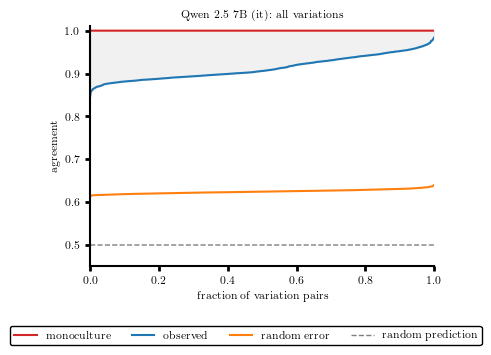

agreement-0-shot-model-meta-llama--Meta-Llama-3-8B-Instruct_tresh_fitted_pos_instances.png


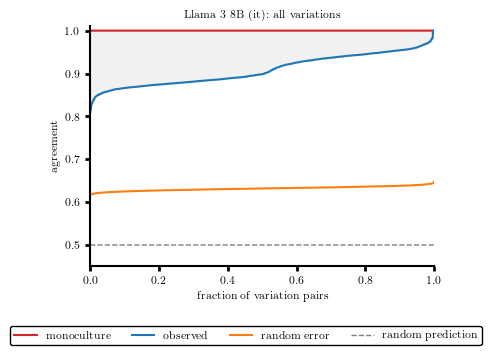

agreement-0-shot-model-meta-llama--Meta-Llama-3.3-70B-Instruct_tresh_fitted_pos_instances.png


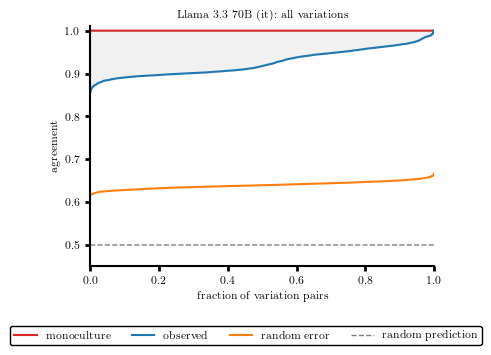

agreement-0-shot-model-Qwen--Qwen2.5-72B-Instruct_tresh_fitted_pos_instances.png


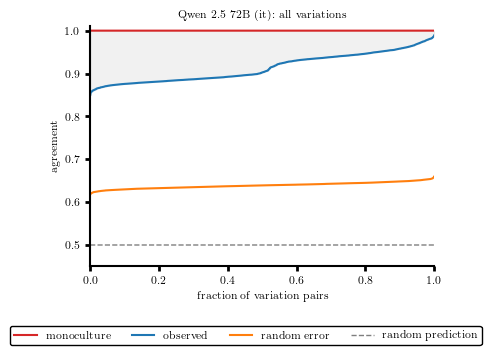

In [337]:
for model in models_to_plot:

    fig, axs = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True, sharey=True)

    predictions_model_variations = (
        df_with_predictions[df_with_predictions["model"] == model]
        .filter(like="score_")
        .transpose()
    )

    variation_indices = predictions_model_variations.columns
    obs_agreement_matrix = matrix_pairwise_evals(
        variation_indices,
        partial(observed_agreement_wrapper, predictions=predictions_model_variations),
    ).fill_diagonal_(torch.nan)
    exp_agreement_matrix = matrix_pairwise_evals(
        variation_indices,
        fun=lambda m1, m2: pairwise_agreement_at_random(
            df_vary_prompt[df_vary_prompt["model"] == model].loc[m1]["accuracy"],
            df_vary_prompt[df_vary_prompt["model"] == model].loc[m2]["accuracy"],
        ),
    ).fill_diagonal_(torch.nan)

    axs = plot_agreement_lineplot(
        axs,
        obs_agreement_matrix[~obs_agreement_matrix.isnan()],
        exp_agreement_matrix[~exp_agreement_matrix.isnan()],
        title=f"{prettify_model_name(key_to_model(model))}: all variations",
        ylabel="agreement",
        xlabel="fraction of variation pairs",
    )

    # legend
    handles, labels = axs.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(labels),
        bbox_to_anchor=(0.5, -0.15),
        frameon=True,  # show box
        framealpha=1.0,  # opacity of box
        edgecolor="black",  # border color
        fancybox=True,
    )  # rounded corners)

    file_name = "".join(
        [
            f"agreement-{num_shots}-shot-model-{model}",
            "_tresh_fitted" if threshold_fitted == 1 else "",
            "_pos_instances" if restrict_to_positive_label else "",
            "_neg_instances" if restrict_to_negative_label else "",
            ".png",
        ]
    )
    plt.savefig(FIGURES_ROOT_DIR / file_name)
    # plt.savefig(FIGURES_PAPER_DIR / file_name)
    print(file_name)

    plt.show()

#### plot for all models

agreement-all-variations-0-shot_tresh_fitted_pos_instances.png


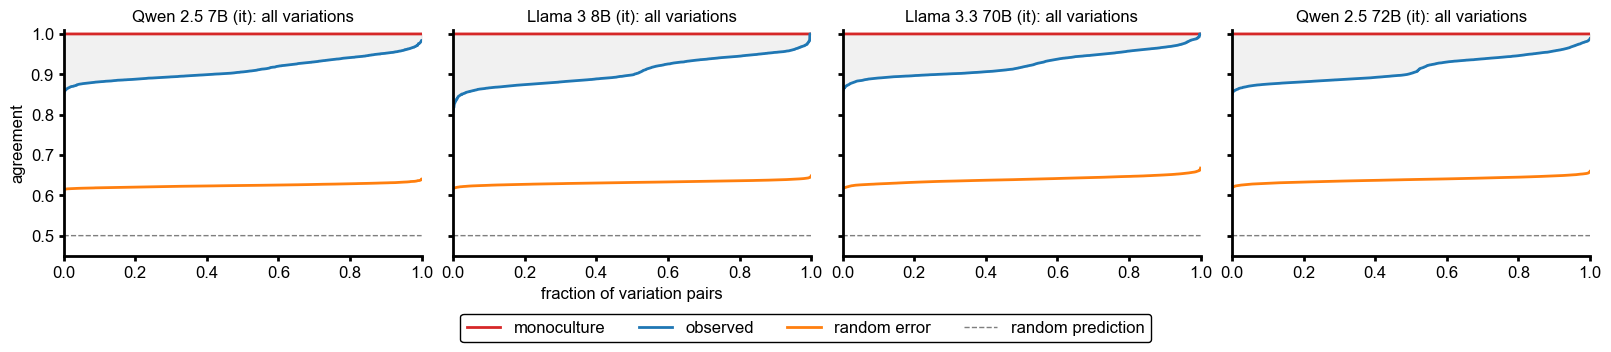

In [88]:
fig, axs = plt.subplots(
    1,
    len(models_to_plot),
    figsize=(4 * len(models_to_plot), 3),
    constrained_layout=True,
    sharey=True,
)

for i, model in enumerate(models_to_plot):
    predictions_model_variations = (
        df_with_predictions[df_with_predictions["model"] == model]
        .filter(like="score_")
        .transpose()
    )

    variation_indices = predictions_model_variations.columns
    obs_agreement_matrix = matrix_pairwise_evals(
        variation_indices,
        partial(observed_agreement_wrapper, predictions=predictions_model_variations),
    ).fill_diagonal_(torch.nan)
    exp_agreement_matrix = matrix_pairwise_evals(
        variation_indices,
        fun=lambda m1, m2: pairwise_agreement_at_random(
            df_vary_prompt[df_vary_prompt["model"] == model].loc[m1]["accuracy"],
            df_vary_prompt[df_vary_prompt["model"] == model].loc[m2]["accuracy"],
        ),
    ).fill_diagonal_(torch.nan)

    axs[i] = plot_agreement_lineplot(
        axs[i],
        obs_agreement_matrix[~obs_agreement_matrix.isnan()],
        exp_agreement_matrix[~exp_agreement_matrix.isnan()],
        title=f"{prettify_model_name(key_to_model(model))}: all variations",
        # ylabel="agreement",
        # xlabel="fraction of variation pairs",
    )

axs[0].set_ylabel("agreement")
axs[len(models_to_plot) // 2 - 1].set_xlabel("fraction of variation pairs")
# legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.15),
    frameon=True,  # show box
    framealpha=1.0,  # opacity of box
    edgecolor="black",  # border color
    fancybox=True,
)  # rounded corners)

file_name = "".join(
    [
        f"agreement-all-variations-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        ".png",
    ]
)
plt.savefig(FIGURES_ROOT_DIR / file_name)
# plt.savefig(FIGURES_PAPER_DIR / file_name)
print(file_name)

plt.show()

#### plot for all models: compare to variation different models

Load predictions for same prompt, varying models and restrict to models within eps error tolerance

In [89]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv")
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["task"] == TASKS[0])
    & (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
display(df_same_prompt.head())
predictions_same_prompt = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

restrict_to_top_eps = True
eps = 0.05
if restrict_to_top_eps:
    for task in TASKS:
        df_task_sorted_by_acc = df_same_prompt[
            df_same_prompt["task"] == task
        ].sort_values(by="accuracy", ascending=False)

        top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
        models = sorted(
            df_task_sorted_by_acc[df_task_sorted_by_acc["accuracy"] > top_acc - eps][
                "model"
            ].to_list(),
            key=get_size_and_it,
        )
        predictions_same_prompt[task] = predictions_same_prompt[task].filter(
            items=models
        )
        print(task, predictions_same_prompt[task].shape)

if any([restrict_to_positive_label, restrict_to_negative_label]):
    for task in TASKS:
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            predictions_same_prompt[task] = predictions_same_prompt[task].loc[
                filter_idx
            ]
            data[task] = (data[task][0].loc[filter_idx], data[task][1].loc[filter_idx])
        print(task, predictions_same_prompt[task].shape)


evals_per_task_same_prompt = {}  # [task][metric][model]
for task in df_same_prompt["task"].unique():
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task_same_prompt[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in ["accuracy"]
    }

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.776744,0.680409,3019759728,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.904552,0.727768,3118177042,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,0.438475,0.510381,3621160589,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,0.867235,0.659718,1712994131,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


ACSIncome (166450, 21)
ACSIncome (61233, 21)


compute agreement matrix for same prompt

In [90]:
from monoculture.analysis.metrics import get_obs_agreement_counts

In [91]:
models_sorted = sorted(predictions_same_prompt[TASKS[0]].columns, key=get_size_and_it)
M_same_prompt = len(models)
# agreements without diagonal
obs_agreement_matrix_same_prompt = matrix_pairwise_evals(
    models_sorted,
    partial(observed_agreement_wrapper, predictions=predictions_same_prompt[TASKS[0]]),
).fill_diagonal_(torch.nan)

observed_same_prompt = obs_agreement_matrix_same_prompt[
    ~obs_agreement_matrix_same_prompt.isnan()
]
M_pairs_same_prompt = len(observed_same_prompt)
recourse_fraction_models_same_prompt = get_obs_agreement_counts(
    predictions_same_prompt[TASKS[0]],
    restrict_only_pos_instances=True,
    true_labels=data[TASKS[0]][1],
)
recourse_fraction_models_same_prompt = sorted(
    recourse_fraction_models_same_prompt / predictions_same_prompt[TASKS[0]].shape[1]
)

plot

Qwen--Qwen2.5-7B-Instruct
meta-llama--Meta-Llama-3-8B-Instruct
meta-llama--Meta-Llama-3.3-70B-Instruct
Qwen--Qwen2.5-72B-Instruct
agreement-all-variations-with-same-prompt-agreement-0-shot_tresh_fitted_pos_instances.png


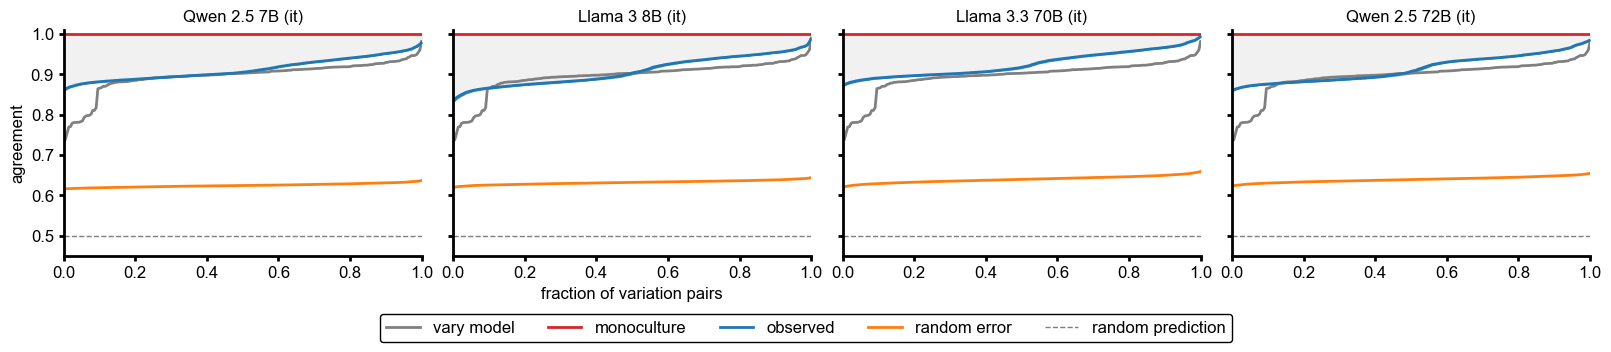

In [92]:
fig, axs = plt.subplots(
    1,
    len(models_to_plot),
    figsize=(4 * len(models_to_plot), 3),
    constrained_layout=True,
    sharey=True,
)

for i, model in enumerate(models_to_plot):
    print(model)
    predictions_model_variations = (
        df_with_predictions[df_with_predictions["model"] == model]
        .filter(like="score_")
        .transpose()
    )

    # for reference plot agreement same prompt, varying models
    fraction_model_pairs = np.arange(0, M_pairs_same_prompt - 1 + 0.01, 1.0) / (
        M_pairs_same_prompt - 1
    )
    axs[i].plot(
        fraction_model_pairs,
        sorted(observed_same_prompt),
        label="vary model",
        color="gray",
    )

    # compute agreement for 10 equally sized variation sets
    variation_indices = predictions_model_variations.columns
    num_samples = 20
    sampled_variation_indices = [
        random.sample(list(variation_indices), M_same_prompt)
        for _ in range(num_samples)
    ]
    agreements_obs = []
    agreements_rand = []
    for sample in sampled_variation_indices:
        obs_agreement_matrix = matrix_pairwise_evals(
            sample,
            partial(
                observed_agreement_wrapper, predictions=predictions_model_variations
            ),
        ).fill_diagonal_(torch.nan)
        exp_agreement_matrix = matrix_pairwise_evals(
            sample,
            fun=lambda m1, m2: pairwise_agreement_at_random(
                df_vary_prompt[df_vary_prompt["model"] == model].loc[m1]["accuracy"],
                df_vary_prompt[df_vary_prompt["model"] == model].loc[m2]["accuracy"],
            ),
        ).fill_diagonal_(torch.nan)
        agreements_obs.append(
            torch.Tensor(sorted(obs_agreement_matrix[~obs_agreement_matrix.isnan()]))
        )
        agreements_rand.append(
            torch.Tensor(sorted(exp_agreement_matrix[~exp_agreement_matrix.isnan()]))
        )

    agreements_obs = torch.stack(agreements_obs)
    agreements_rand = torch.stack(agreements_rand)
    stderr = agreements_obs.std(dim=0) / np.sqrt(num_samples)
    axs[i] = plot_agreement_lineplot(
        axs[i],
        agreements_obs.mean(dim=0),
        agreements_rand.mean(dim=0),
        title=f"{prettify_model_name(key_to_model(model))}",
        # ylabel="agreement",
        # xlabel="fraction of variation pairs",
    )
    axs[i].fill_between(
        fraction_model_pairs,
        agreements_obs.mean(dim=0) - stderr,
        agreements_obs.mean(dim=0) + stderr,
        color="C0",
        alpha=0.7,
    )

axs[0].set_ylabel("agreement")
axs[len(models_to_plot) // 2 - 1].set_xlabel("fraction of variation pairs")
# legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.15),
    frameon=True,  # show box
    framealpha=1.0,  # opacity of box
    edgecolor="black",  # border color
    fancybox=True,
)  # rounded corners)

file_name = "".join(
    [
        f"agreement-all-variations-with-same-prompt-agreement-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        ".png",
    ]
)
plt.savefig(FIGURES_ROOT_DIR / file_name)
plt.savefig(FIGURES_PAPER_DIR / file_name)
print(file_name)

plt.show()

## Recourse

In [29]:
logging.basicConfig(level=logging.ERROR, force=True)

Qwen--Qwen2.5-7B-Instruct
meta-llama--Meta-Llama-3-8B-Instruct
meta-llama--Meta-Llama-3.3-70B-Instruct
Qwen--Qwen2.5-72B-Instruct
recourse-all-variations-0-shot_tresh_fitted_pos_instances.png


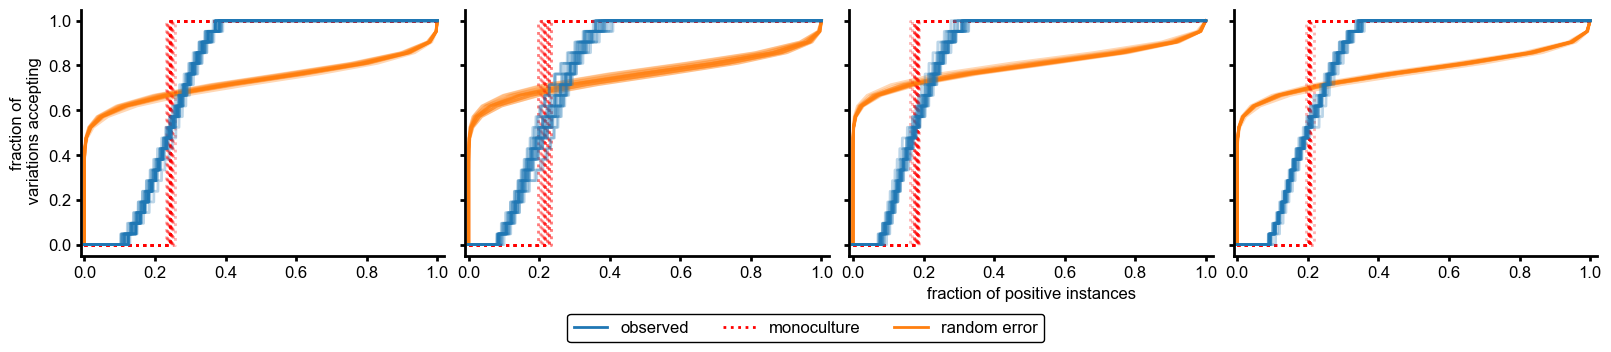

In [51]:
fig, axs = plt.subplots(
    1,
    len(models_to_plot),
    figsize=(4 * len(models_to_plot), 3),
    constrained_layout=True,
    sharey=True,
)

for i, model in enumerate(models_to_plot):
    print(model)
    predictions_model_variations = (
        df_with_predictions[df_with_predictions["model"] == model]
        .filter(like="score_")
        .transpose()
    )
    predictions_model_variations.index = predictions_model_variations.index.str.replace(
        r"^score_", "", regex=True
    ).astype(int)

    variation_indices = predictions_model_variations.columns
    num_samples = 20
    sampled_variation_indices = [
        random.sample(list(variation_indices), M_same_prompt)
        for _ in range(num_samples)
    ]
    # sample = sampled_variation_indices[0]

    for sample in sampled_variation_indices:

        tp_rates = [
            1.0 - df_vary_prompt[df_vary_prompt["model"] == model].loc[var_idx]["fnr"]
            for var_idx in sample
        ]

        axs[i], obs, at_rand = plot_recourse_lineplot(
            axs[i],
            predictions_model_variations[sample],
            baseline_rates=tp_rates,
            y_true=data[task][1],
            restrict_only_pos_instances=True,
            restrict_only_neg_instances=False,
            count_accepted=True,
            at_least=False,
            plot_pdf=False,
            show_monoc=True,
            alpha=0.3,
            xlabel="",
            ylabel="",
        )
        # print(f"all models agree (0 or 1): {(predictions_model_variations[sample].nunique(axis=1) ==1).sum()/predictions_model_variations.shape[0]}\n"
        #       f"all models accept: {(predictions_model_variations[sample].sum(axis=1) == M_same_prompt).sum()/predictions_model_variations.shape[0]}\n"
        #       f"all models reject: {(predictions_model_variations[sample].sum(axis=1) == 0).sum()/predictions_model_variations.shape[0]}\n")

axs[0].set_ylabel("fraction of\n variations accepting")
axs[len(models_to_plot) // 2].set_xlabel("fraction of positive instances")
# legend
handles, labels = axs[0].get_legend_handles_labels()
unique_labels = []
unique_handles = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        handle.set_alpha(1.0)
        unique_labels.append(label)
        unique_handles.append(handle)
fig.legend(
    unique_handles,
    unique_labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.15),
    frameon=True,  # show box
    framealpha=1.0,  # opacity of box
    edgecolor="black",  # border color
    fancybox=True,
)  # rounded corners)

file_name = "".join(
    [
        f"recourse-all-variations-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        ".png",
    ]
)
# plt.savefig(FIGURES_ROOT_DIR / file_name)
# plt.savefig(FIGURES_PAPER_DIR / file_name)
print(file_name)

plt.show()

Qwen--Qwen2.5-7B-Instruct
0.001525634446254993
meta-llama--Meta-Llama-3-8B-Instruct
0.002062532467224316
meta-llama--Meta-Llama-3.3-70B-Instruct
0.0011628780394154882
Qwen--Qwen2.5-72B-Instruct
0.0007240773126977493
recourse-all-variations-0-shot_tresh_fitted_pos_instances.png


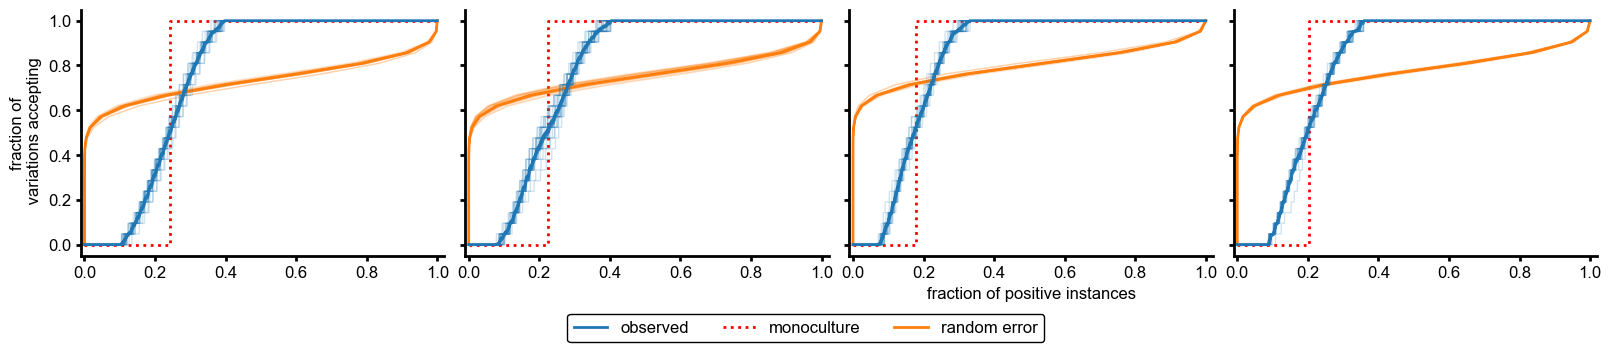

In [ ]:
from monoculture.analysis.plotting import plot_recourse_lineplot_mean_stderr

fig, axs = plt.subplots(
    1,
    len(models_to_plot),
    figsize=(4 * len(models_to_plot), 3),
    constrained_layout=True,
    sharey=True,
)

for i, model in enumerate(models_to_plot):
    print(model)
    predictions_model_variations = (
        df_with_predictions[df_with_predictions["model"] == model]
        .filter(like="score_")
        .transpose()
    )
    predictions_model_variations.index = predictions_model_variations.index.str.replace(
        r"^score_", "", regex=True
    ).astype(int)

    variation_indices = predictions_model_variations.columns
    num_samples = 20
    sampled_variation_indices = [
        random.sample(list(variation_indices), M_same_prompt)
        for _ in range(num_samples)
    ]

    tp_rates = [
        [
            1.0 - df_vary_prompt[df_vary_prompt["model"] == model].loc[var_idx]["fnr"]
            for var_idx in sample
        ]
        for sample in sampled_variation_indices
    ]

    axs[i], obs, at_rand = plot_recourse_lineplot_mean_stderr(
        axs[i],
        [predictions_model_variations[sample] for sample in sampled_variation_indices],
        baseline_rates=tp_rates,
        y_true=data[task][1],
        restrict_only_pos_instances=True,
        restrict_only_neg_instances=False,
        count_accepted=True,
        at_least=False,
        plot_pdf=False,
        show_monoc=True,
        alpha=1.0,
        xlabel="",
        ylabel="",
    )
    # print(f"all models agree (0 or 1): {(predictions_model_variations[sample].nunique(axis=1) ==1).sum()/predictions_model_variations.shape[0]}\n"
    #           f"all models accept: {(predictions_model_variations[sample].sum(axis=1) == M_same_prompt).sum()/predictions_model_variations.shape[0]}\n"
    #           f"all models reject: {(predictions_model_variations[sample].sum(axis=1) == 0).sum()/predictions_model_variations.shape[0]}\n")

axs[0].set_ylabel("fraction of\n variations accepting")
axs[len(models_to_plot) // 2].set_xlabel("fraction of positive instances")
# legend
handles, labels = axs[0].get_legend_handles_labels()
unique_labels = []
unique_handles = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        handle.set_alpha(1.0)
        unique_labels.append(label)
        unique_handles.append(handle)
fig.legend(
    unique_handles,
    unique_labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.15),
    frameon=True,  # show box
    framealpha=1.0,  # opacity of box
    edgecolor="black",  # border color
    fancybox=True,
)  # rounded corners)

file_name = "".join(
    [
        f"recourse-all-variations-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        ".png",
    ]
)
plt.savefig(FIGURES_ROOT_DIR / file_name)
# plt.savefig(FIGURES_PAPER_DIR / file_name)
print(file_name)

plt.show()

## Agreement and Recourse

Qwen--Qwen2.5-7B-Instruct
tensor([ 7514.,  1064.,   785.,   784.,   789.,   670.,   628.,   625.,   763.,
          608.,   557.,   578.,   612.,   892.,   683.,   692.,   686.,   883.,
          945.,  1055.,  1219., 38201.])
[ 7352.8   1324.3    928.15   796.15   728.75   673.8    657.4    669.
   701.     672.65   664.2    654.75   670.25   675.8    677.1    680.55
   681.8    738.     816.4   1003.2   1425.3  38041.65]
61233
meta-llama--Meta-Llama-3-8B-Instruct
tensor([ 7140.,   956.,   709.,   713.,   620.,   567.,   538.,   568.,   650.,
          623.,  1517.,   933.,   738.,   790.,   574.,   699.,   743.,   840.,
          846.,  1346.,  1430., 37693.])
[ 6940.5   1025.8    817.75   701.5    694.05   669.65   773.5    726.6
   813.95   771.7    708.05   726.6    637.55   687.6    657.9    677.9
   714.55   789.2    944.3   1186.1   1862.8  37705.45]
61233
meta-llama--Meta-Llama-3.3-70B-Instruct
tensor([ 5478.,   785.,   582.,   541.,   398.,   405.,   392.,   484.,   884.,
   

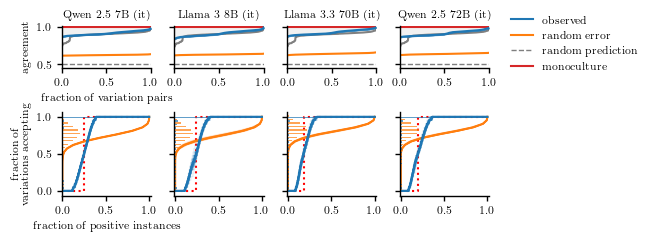

In [365]:
default_width = plt.rcParams['figure.figsize'][0]*0.9
# Set custom height
custom_height = 2.3 #plt.rcParams['figure.figsize'][1]

fig, axs = plt.subplots(
    2,
    len(models_to_plot),
    figsize=(default_width, custom_height),
    constrained_layout=True,
    gridspec_kw={'height_ratios': [1,2]},
    sharey="row",
)
legend = True

recourse_observed = {}
recourse_at_random = {}
for m, model in enumerate(models_to_plot):
    print(model)

    predictions_model_variations = (
            df_with_predictions[df_with_predictions["model"] == model]
            .filter(like="score_")
            .transpose()
        )
    predictions_model_variations.index = predictions_model_variations.index.str.replace(
            r"^score_", "", regex=True
        ).astype(int)

    for i in range(2):
        ax = axs[i, m]
        if i == 0: # plot agreement
            # for reference plot agreement same prompt, varying models
            fraction_model_pairs = np.arange(0, M_pairs_same_prompt - 1 + 0.01, 1.0) / (
                M_pairs_same_prompt - 1
            )
            ax.plot(
                fraction_model_pairs,
                sorted(observed_same_prompt),
                label="vary model",
                color="gray",
                zorder=-2
            )

            # compute agreement for 10 equally sized variation sets
            variation_indices = predictions_model_variations.columns
            num_samples = 20
            sampled_variation_indices = [
                random.sample(list(variation_indices), M_same_prompt)
                for _ in range(num_samples)
            ]
            agreements_obs = []
            agreements_rand = []
            for sample in sampled_variation_indices:
                obs_agreement_matrix = matrix_pairwise_evals(
                    sample,
                    partial(
                        observed_agreement_wrapper, predictions=predictions_model_variations
                    ),
                ).fill_diagonal_(torch.nan)
                exp_agreement_matrix = matrix_pairwise_evals(
                    sample,
                    fun=lambda m1, m2: pairwise_agreement_at_random(
                        df_vary_prompt[df_vary_prompt["model"] == model].loc[m1]["accuracy"],
                        df_vary_prompt[df_vary_prompt["model"] == model].loc[m2]["accuracy"],
                    ),
                ).fill_diagonal_(torch.nan)
                agreements_obs.append(
                    torch.Tensor(sorted(obs_agreement_matrix[~obs_agreement_matrix.isnan()]))
                )
                agreements_rand.append(
                    torch.Tensor(sorted(exp_agreement_matrix[~exp_agreement_matrix.isnan()]))
                )

            agreements_obs = torch.stack(agreements_obs)
            agreements_rand = torch.stack(agreements_rand)
            stderr = agreements_obs.std(dim=0) / np.sqrt(num_samples)
            ax = plot_agreement_lineplot(
                ax,
                agreements_obs.mean(dim=0),
                agreements_rand.mean(dim=0),
                title=f"{prettify_model_name(key_to_model(model))}",
                # ylabel="agreement",
                # xlabel="fraction of variation pairs",
            )
            ax.fill_between(
                fraction_model_pairs,
                agreements_obs.mean(dim=0) - stderr,
                agreements_obs.mean(dim=0) + stderr,
                color="C0",
                alpha=0.7,
            )
        else: # plot recourse
            tp_rates = [
                [
                    1.0 - df_vary_prompt[df_vary_prompt["model"] == model].loc[var_idx]["fnr"]
                    for var_idx in sample
                ]
                for sample in sampled_variation_indices
            ]

            ax, obs, at_rand = plot_recourse_lineplot_mean_stderr(
                ax,
                [predictions_model_variations[sample] for sample in sampled_variation_indices],
                baseline_rates=tp_rates,
                y_true=data[task][1],
                restrict_only_pos_instances=True,
                restrict_only_neg_instances=False,
                count_accepted=True,
                at_least=False,
                plot_pdf=True,
                show_monoc=True,
                alpha=1.0,
                xlabel="",
                ylabel="",
                num_ticks = 3,
            )
            recourse_observed[model] = obs
            recourse_at_random[model] = at_rand

axs[0, 0].set_ylabel("agreement")
axs[0, 0].set_xlabel("fraction of variation pairs")

axs[1, 0].set_ylabel("fraction of\n variations accepting")
axs[1, 0].set_xlabel("fraction of positive instances")

# # xlabel
# pos_left = axs[0,0].get_position()
# pos_right= axs[0,-1].get_position()
# fig.text((pos_left.x0 + pos_right.x1)/2, pos_left.y0 - 0.03, "fraction of variation pairs", ha='center', va='top')

# axs[1, 0].set_ylabel("fraction of\n variations accepting")
# pos_left = axs[1,0].get_position()
# pos_right= axs[1,-1].get_position()
# fig.text((pos_left.x0 + pos_right.x1)/2, pos_left.y0 - 0.03, "fraction of positive instances", ha='center', va='top')

if legend: 
    # legend
    desired_order = ['observed', 'random error', 'random prediction', 'monoculture']
    handles, labels = axs[0,0].get_legend_handles_labels()
    unique = {}
    for h, l in zip(handles, labels):
        if l not in unique:
            unique[l] = h
    ordered_labels = [label for label in desired_order if label in unique]
    ordered_handles = [unique[label] for label in ordered_labels]
    # positioning
    # get the bottom-most y-position among all axes
    lowest_ax_y = min([ax.get_position().y0 for ax in axs.flat])

    fig.legend(
        ordered_handles,
        ordered_labels,
        loc="upper left",
        # ncol=len(labels),
        bbox_to_anchor=(1.0, 1.0),
        # loc="lower center",
        # ncol=len(labels),
        # bbox_to_anchor=(0.5, lowest_ax_y-0.22),
        frameon=False,  # show box
        framealpha=1.0,  # opacity of box
        edgecolor="black",  # border color
        fancybox=True,
    )  # rounded corners)

file_name = "".join(
    [
        f"agreement-recourse-all-variations-with-same-prompt-agreement-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
    ]
)
for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_ROOT_DIR / (file_name + ending))
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()

In [161]:
print(f"{'model':15}&\tno recourse & limited recourse (majority rejects) & full recourse\\\\")
for model in recourse_observed.keys():
    print(f"{prettify_model_name(key_to_model(model)):15} &\t{recourse_observed[model][recourse_observed[model][:,1] == 0.0][-1][0]:.4f}&\t{recourse_observed[model][recourse_observed[model][:,1] <= 0.5][-1][0]:.4f} &\t{1. - recourse_observed[model][recourse_observed[model][:,1] == 1.0][0][0]:.4f}\\\\")

model          &	no recourse & limited recourse (majority rejects) & full recourse\\
Qwen 2.5 7B (it) &	0.1132&	0.2463 &	0.6078\\
Llama 3 8B (it) &	0.1079&	0.2329 &	0.5900\\
Llama 3.3 70B (it) &	0.0834&	0.1776 &	0.6738\\
Qwen 2.5 72B (it) &	0.0838&	0.1954 &	0.6350\\


In [ ]:
frac_accepted_vary = predictions_model_variations[sampleM].sum(axis=1)/predictions_model_variations.shape[1]
frac_accepted_same = predictions_same_prompt[TASKS[0]].sum(axis=1)/predictions_same_prompt[TASKS[0]].shape[1]

In [177]:
# for how many that have previously not been accepted by all different models, did the fraction of variations increase
cond = frac_accepted_same != 1
sum(frac_accepted_same[cond] < frac_accepted_vary[cond])/cond.sum()

0.5771877729257642

In [ ]:
# for how many that had been accepted by all decreases the acceptance 
cond = frac_accepted_same == 1
sum(frac_accepted_same[cond] > frac_accepted_vary[cond])/cond.sum()

0.052195780176643766

In [179]:
# for how many that have previously been rejected by all different models, did the fraction of variations increase
cond = frac_accepted_same == 0 
sum(frac_accepted_same[cond] < frac_accepted_vary[cond])/cond.sum()

0.2296155471060414

Qwen--Qwen2.5-7B-Instruct
meta-llama--Meta-Llama-3-8B-Instruct
meta-llama--Meta-Llama-3.3-70B-Instruct
Qwen--Qwen2.5-72B-Instruct
delta-recourse-variations-with-same-prompt-0-shot_tresh_fitted_pos_instances


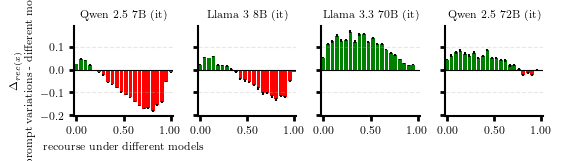

In [326]:
default_width = plt.rcParams['figure.figsize'][0]
# Set custom height
custom_height = 1.5 #plt.rcParams['figure.figsize'][1]

fig, axs = plt.subplots(
    1,
    len(models_to_plot),
    figsize=(default_width, custom_height),
    constrained_layout=True,
    sharey="row",
    sharex=True
)
legend = True


M = predictions_same_prompt[TASKS[0]].shape[1] # num different models
ms = range(0, M + 1)
ticks_indices = np.linspace(0,M, num=3)
num_samples = 20  # number of samples of size M

# Aggregate predictions
before = predictions_same_prompt[TASKS[0]].sum(axis=1).values

for m, ax in enumerate(axs.flat):
    model = models_to_plot[m]
    print(model)

    predictions_model_variations = (
            df_with_predictions[df_with_predictions["model"] == model]
            .filter(like="score_")
            .transpose()
        )
    predictions_model_variations.index = predictions_model_variations.index.str.replace(
            r"^score_", "", regex=True
        ).astype(int)
    

    # Initialize lists to store means and variations (standard deviation across samples)
    means = []
    variations = []

    # Loop over each possible count of positive predictions before (m)
    mean_deltas_per_sample = []
    for _ in range(num_samples):
        sample_variations = np.random.choice(np.array(predictions_model_variations.columns), size=M, replace=False)
        after = predictions_model_variations[sample_variations].sum(axis=1).values
        deltas = []
        for m in ms:
            idx = np.where(before == m)[0]
            mean_delta = (after[idx] - before[idx]).mean()/M
            deltas.append(mean_delta)
        mean_deltas_per_sample.append(deltas)

    mean_samples = np.array(mean_deltas_per_sample).mean(axis=0)
    stderr_samples = np.array(mean_deltas_per_sample).std(axis=0)/np.sqrt(num_samples)

    ax.bar(ms, mean_samples, yerr=stderr_samples, color=['green' if val >= 0 else 'red' for val in mean_samples])
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax.set_title(f"{prettify_model_name(key_to_model(model))}")

axs[0].set_xticks(ticks_indices, [f"{m/M:.2f}" for m in ticks_indices])
axs[0].set_xlim(-0.5,M+0.5)
axs[0].set_xlabel("recourse under different models")
axs[0].set_ylabel("$\Delta_{rec(x)}$" "\n(prompt variations - different models)")

file_name = "".join(
    [
        f"delta-recourse-variations-with-same-prompt-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
    ]
)
# for ending in [".png", ".pdf"]:
#     plt.savefig(FIGURES_ROOT_DIR / (file_name + ending))
#     plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()